# USD SOFR OIS Curve Construction

This notebook constructs the USD SOFR discount curve used throughout the model-validation project.

The curve is built from:

- **LCH SwapClear settlement par rates** at standard short- and long-end maturities;
- **CFTC SDR spot-starting SOFR OIS transactions** to fill the 3M–3Y gap in the LCH standard maturity set.

The final curve is represented using **PCHIP interpolation of log discount factors** and is required to reproduce the selected market par rates while maintaining positive, monotonically decreasing discount factors.

The resulting curve is subsequently used for swap valuation, Hull–White calibration, and CCR exposure calculations.

In [1]:
import numpy as np
import pandas as pd

from pathlib import Path

from scipy.interpolate import PchipInterpolator
from scipy.optimize import brentq, least_squares

from ccr_validation.curves import DiscountCurve
from ccr_validation.swaps import fixed_leg_schedule

import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

plt.style.use("bmh")

plt.rcParams.update({
    "figure.figsize": (9, 5),
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
    "text.usetex": True,
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
})

## 1. Market date and conventions

The valuation date is **2 September 2026**, represented by time $0$. The OIS instruments are treated as **T+2 spot-starting**, giving an effective date of **4 September 2026**, represented by $T_0$.

Tenors are measured from the spot date; curve times $T_i$ are measured from valuation time $0$ using ACT/365F. Fixed-leg accrual fractions $\alpha_i$ use ACT/360.

### Simplifying assumptions

For the purposes of this project:

- fixed-leg payments are annual with ACT/360 accrual;
- business-day adjustments are not explicitly modelled;
- payment lag is taken to be zero;
- quoted tenors are converted to natural calendar dates from the spot date.

These simplifications are adequate for the present model-validation objective, but a production curve would use the full market calendar and payment conventions.

In [2]:
market_date = pd.Timestamp("2026-09-02")
spot_date = pd.Timestamp("2026-09-04")

## 2. LCH SwapClear SOFR OIS settlement rates

LCH SwapClear settlement prices for 2 September 2026 provide USD SOFR OIS par rates across a broad maturity range.

The raw maturity set contains both standard maturities and an additional irregular strip of intermediate maturities. Earlier diagnostics showed that treating the entire irregular strip as homogeneous spot-starting OIS curve instruments produced implausible local forward-rate behaviour.

The baseline curve therefore retains only the clearly identifiable standard maturity set:

- short-end maturities through 3M;
- whole-year maturities from 3Y onward.

This leaves a substantial **3M–3Y gap**, which is filled independently using same-day CFTC SOFR OIS transactions.

In [3]:
data_path = Path("../data/raw/2026-09-02")

lch_path = data_path / "lch_usd_sofr_ois_2026-09-02.csv"

ois = pd.read_csv(lch_path)
ois.head(20)

,business_day,currency,product_type,maturity,quantation_basis,par_rate_pct
0,"Sep 02, 2026",USD,OIS,1 day,Anl Mny / SOFR,3.66000
1,"Sep 02, 2026",USD,OIS,1 month,Anl Mny / SOFR,3.73767
2,"Sep 02, 2026",USD,OIS,1 week,Anl Mny / SOFR,3.63073
3,"Sep 02, 2026",USD,OIS,10 year,Anl Mny / SOFR,4.41500
4,"Sep 02, 2026",USD,OIS,12 year,Anl Mny / SOFR,4.47900
5,"Sep 02, 2026",USD,OIS,15 year,Anl Mny / SOFR,4.56200
6,"Sep 02, 2026",USD,OIS,2 day,Anl Mny / SOFR,3.66000
7,"Sep 02, 2026",USD,OIS,2 month,Anl Mny / SOFR,3.78811
8,"Sep 02, 2026",USD,OIS,2 week,Anl Mny / SOFR,3.64587
9,"Sep 02, 2026",USD,OIS,20 year,Anl Mny / SOFR,4.63100


In [4]:
def maturity_date(
    market_date: pd.Timestamp,
    maturity: str,
) -> pd.Timestamp:

    n_str, unit = maturity.split()
    n = int(n_str)

    if unit.startswith("day"):
        return market_date + pd.Timedelta(days=n)

    if unit.startswith("week"):
        return market_date + pd.Timedelta(weeks=n)

    if unit.startswith("month"):
        return market_date + pd.DateOffset(months=n)

    if unit.startswith("year"):
        return market_date + pd.DateOffset(years=n)

    raise ValueError(f"Unknown maturity: {maturity}")

ois["maturity_date"] = ois["maturity"].apply(lambda x: maturity_date(spot_date, x))

ois["time"] = (ois["maturity_date"] - market_date).dt.days / 365.0

ois["par_rate"] = ois["par_rate_pct"] / 100.0

C:\Users\Bertrand\AppData\Local\Temp\ipykernel_17360\4033937444.py:10: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  return market_date + pd.Timedelta(days=n)
C:\Users\Bertrand\AppData\Local\Temp\ipykernel_17360\4033937444.py:13: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  return market_date + pd.Timedelta(weeks=n)


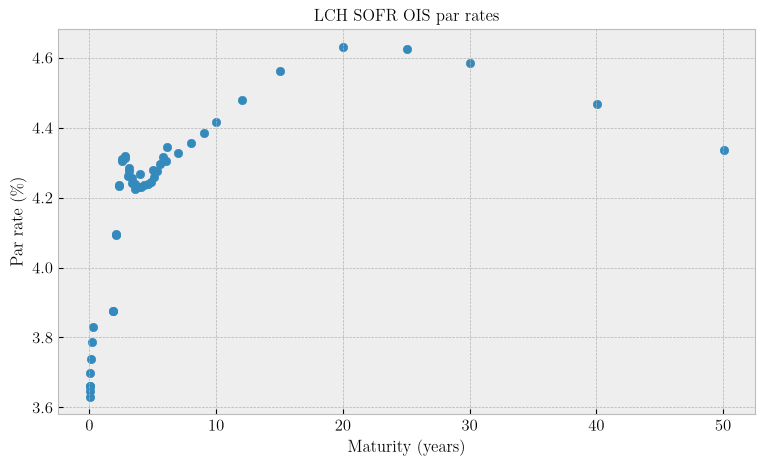

In [5]:
plt.scatter(ois["time"], ois["par_rate_pct"])

plt.xlabel("Maturity (years)")
plt.ylabel("Par rate (\\%)")
plt.title("LCH SOFR OIS par rates")
plt.grid(True)
plt.show()

### Standard maturity selection

The raw LCH maturity set is split into the standard nodes retained for curve construction and the irregular intermediate strip excluded from the baseline.

The plot below is used as a data-quality diagnostic only; exclusion of the irregular strip is based on the instrument-specification and forward-curve diagnostics described above.

In [6]:
standard_maturities = [
    "1 day", "2 day",
    "1 week", "2 week", "3 week",
    "1 month", "2 month", "3 month",
    "3 year", "4 year", "5 year", "6 year", "7 year", "8 year", "9 year",
    "10 year", "12 year", "15 year", "20 year", "25 year",
    "30 year", "40 year", "50 year",
]

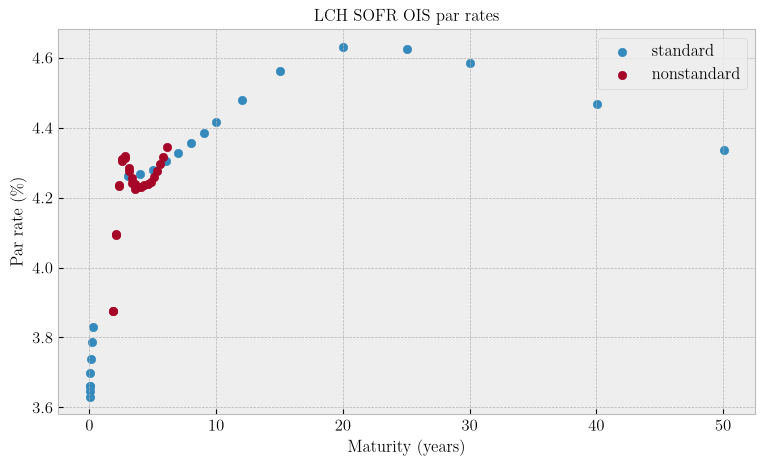

In [7]:
ois_standard = (
    ois[ois["maturity"].isin(standard_maturities)]
    .copy()
    .sort_values("time")
    .reset_index(drop=True)
)

ois_nonstandard = (
    ois[~ois["maturity"].isin(standard_maturities)]
    .copy()
    .sort_values("time")
    .reset_index(drop=True)
)

plt.scatter(ois_standard["time"], ois_standard["par_rate_pct"], label="standard")
plt.scatter(ois_nonstandard["time"], ois_nonstandard["par_rate_pct"], label="nonstandard")

plt.xlabel("Maturity (years)")
plt.ylabel("Par rate (\\%)")
plt.title("LCH SOFR OIS par rates")
plt.legend()
plt.grid(True)
plt.show()

## 3. CFTC SOFR OIS transactions

The missing intermediate maturities are obtained from publicly reported CFTC SDR interest-rate transactions executed on 2 September 2026.

The initial filter selects:

- interest-rate (`IR`) trades;
- new trade events;
- USD SOFR OIS products;
- execution date equal to the curve valuation date.

The fixed coupon is taken from whichever fixed-rate leg field is populated.

The **Execution Timestamp** is used to identify the trading date. The reported Effective Date is retained separately so that the actual start convention can be examined rather than assumed.

In [8]:
cftc_path = data_path / "CFTC_CUMULATIVE_RATES_2026_09_02.csv"

cftc_rates = pd.read_csv(cftc_path, low_memory=False)

In [9]:
date_cols = [
    "Event timestamp",
    "Execution Timestamp",
    "Effective Date",
    "Expiration Date",
    "Maturity date of the underlier",
    "First exercise date",
]

for col in date_cols:
    cftc_rates[col] = pd.to_datetime(
        cftc_rates[col],
        errors="coerce",
        utc=(col == "Event timestamp"),
    )

In [10]:
usd_sofr_compound = ["USD-SOFR-OIS Compound", "USD-SOFR-COMPOUND"]

ois_trades = cftc_rates[
    (cftc_rates["Asset Class"] == "IR")
    & (cftc_rates["Event type"] == "TRAD")
    & (cftc_rates["Action type"].isin(["NEWT", "NEW"]))
    & (cftc_rates["UPI FISN"] == "NA/Swap OIS USD")
    & (cftc_rates["UPI Underlier Name"].isin(usd_sofr_compound))
    & (cftc_rates["Execution Timestamp"].dt.date == market_date.date())
].copy()

ois_trades = ois_trades.rename(columns={
    "Effective Date": "effective_date",
    "Expiration Date": "maturity_date"
})

ois_trades["fixed_rate"] = (
    pd.to_numeric(ois_trades["Fixed rate-Leg 1"], errors="coerce")
    .combine_first(
        pd.to_numeric(ois_trades["Fixed rate-Leg 2"], errors="coerce")
    )
)

execution_date = (
    ois_trades["Execution Timestamp"]
    .dt.tz_localize(None)
    .dt.normalize()
)

In [11]:
print(ois_trades["fixed_rate"].describe())

count    3774.000000
mean        0.042157
std         0.003331
min         0.006560
25%         0.040807
50%         0.042785
75%         0.044112
max         0.072300
Name: fixed_rate, dtype: float64


### Spot-starting trade selection

For each transaction,

$$\text{start lag} = \text{Effective Date} - \text{Execution Date}.$$

The dominant observation is a two-day start lag, consistent with T+2 spot-starting SOFR OIS.

The baseline sample therefore retains trades that are:

- T+2 spot-starting;
- reported with standardised terms;
- non-package trades;
- populated with valid fixed rates and dates.

In [12]:
ois_trades["start_lag_days"] = (ois_trades["effective_date"] - execution_date).dt.days

print(ois_trades["start_lag_days"].value_counts().head(10), "\n")

print(ois_trades.loc[
    ois_trades["start_lag_days"].between(-2, 10),
    "start_lag_days"
].value_counts().sort_index())

start_lag_days
 2      1518
 14      633
 105     269
 196     123
 1        66
 120      52
 0        50
 378      43
-1        28
 90       24
Name: count, dtype: int64 

start_lag_days
-2      15
-1      28
 0      50
 1      66
 2    1518
 6      23
 7       7
 8      18
 9       2
Name: count, dtype: int64


In [13]:
spot_ois = ois_trades[
    (ois_trades["start_lag_days"] == 2)
    & (ois_trades["Non-standardized term indicator"] == False)
    & (ois_trades["Package indicator"] == False)
    & ois_trades["fixed_rate"].notna()
    & ois_trades["effective_date"].notna()
    & ois_trades["maturity_date"].notna()
].copy()

print("Spot-starting clean OIS:", len(spot_ois))

Spot-starting clean OIS: 390


In [14]:
spot_ois["tenor_days"] = (spot_ois["maturity_date"] - spot_ois["effective_date"]).dt.days

spot_ois["tenor_years"] = spot_ois["tenor_days"] / 365.0

spot_ois["tenor_months_approx"] = (spot_ois["tenor_years"] * 12).round().astype(int)

spot_ois["tenor_months_approx"].value_counts().sort_index().head(20)

tenor_months_approx
0      2
1     19
2      5
3     17
4      4
5      3
6     21
9      7
12    37
15     4
18     4
21     3
24    49
26     1
31     1
33     1
34     1
36    20
42     1
44     1
Name: count, dtype: int64

### Standard-tenor identification

Transaction tenor is measured from the reported effective date to the reported maturity date.

The curve gap is populated using the standard tenors

$$6M,\ 9M,\ 12M,\ 15M,\ 18M,\ 21M,\ 24M,$$

with $36M$ retained as an independent overlap check.

For each target tenor, the reported maturity date is compared with the natural calendar maturity implied by

$$\text{Effective Date}+\text{Target Tenor}.$$

A tolerance of three calendar days is allowed to accommodate small date adjustments around the standard maturity.

The full business-day calendar is not reconstructed in this notebook.

In [15]:
target_tenors = {
    6: pd.DateOffset(months=6),
    9: pd.DateOffset(months=9),
    12: pd.DateOffset(years=1),
    15: pd.DateOffset(months=15),
    18: pd.DateOffset(months=18),
    21: pd.DateOffset(months=21),
    24: pd.DateOffset(years=2),
    36: pd.DateOffset(years=3),
}

standard_parts = []

for months, offset in target_tenors.items():

    tmp = spot_ois.copy()

    expected_maturity = tmp["effective_date"] + offset

    date_error = (tmp["maturity_date"] - expected_maturity).dt.days.abs()

    tmp = tmp[date_error <= 3].copy()
    tmp["tenor_months"] = months

    standard_parts.append(tmp)

standard_gap_trades = pd.concat(standard_parts, ignore_index=True)

### Transaction aggregation

Multiple transactions can occur at the same tenor during the trading day. A single representative curve quote is therefore obtained using the **median fixed coupon** at each standard tenor.

The median is preferred to a notional-weighted average because:

- public SDR notionals may be capped or otherwise distorted by reporting rules;
- individual transaction rates can contain outliers;
- the objective is to recover a representative same-day market level rather than a volume-weighted execution benchmark.

The tenor-level dispersion statistics below are retained as a data-quality diagnostic.

In [16]:
rate_summary = (
    standard_gap_trades
    .groupby("tenor_months")["fixed_rate"]
    .agg(
        n="count",
        median="median",
        mean="mean",
        std="std",
        min="min",
        max="max",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
    )
    .reset_index()
)

rate_summary["iqr_bp"] = 1e4 * (rate_summary["q75"] - rate_summary["q25"])

rate_summary

,tenor_months,n,median,mean,std,min,max,q25,q75,iqr_bp
0,6,19,0.039844,0.039941,0.000586,0.039597,0.042340,0.039815,0.039858,0.4295
1,9,7,0.040958,0.040901,0.000104,0.040715,0.040990,0.040857,0.040967,1.0990
2,12,35,0.041796,0.041470,0.001893,0.030600,0.041897,0.041703,0.041874,1.7095
3,15,4,0.042001,0.041978,0.000070,0.041876,0.042035,0.041965,0.042015,0.4985
4,18,4,0.042287,0.042254,0.000095,0.042116,0.042328,0.042234,0.042307,0.7335
5,21,3,0.042361,0.042363,0.000003,0.042361,0.042367,0.042361,0.042364,0.0280
6,24,49,0.042564,0.042586,0.000091,0.042371,0.042714,0.042533,0.042662,1.2920
7,36,20,0.042649,0.042670,0.000071,0.042584,0.042774,0.042611,0.042747,1.3625


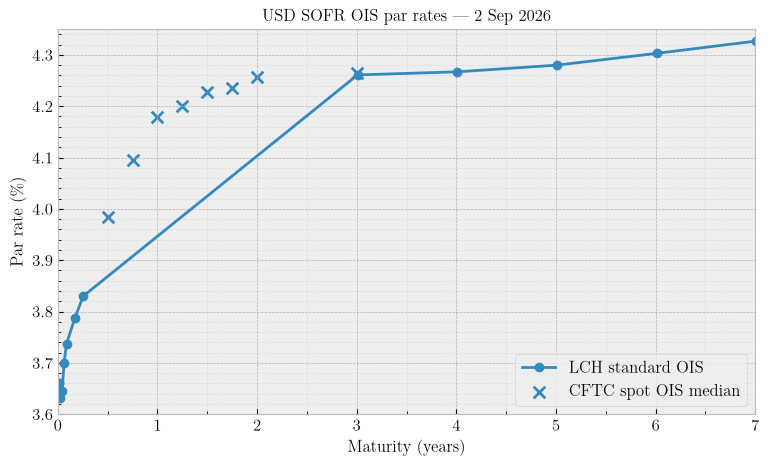

In [17]:
lch_plot = ois_standard[["time", "par_rate"]].copy()

cftc_plot = (
    standard_gap_trades
    .groupby("tenor_months")["fixed_rate"]
    .median()
    .reset_index()
)

cftc_plot["time"] = cftc_plot["tenor_months"] / 12.0

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    lch_plot["time"],
    100 * lch_plot["par_rate"],
    marker="o",
    label="LCH standard OIS",
)

ax.scatter(
    cftc_plot["time"],
    100 * cftc_plot["fixed_rate"],
    marker="x",
    s=70,
    label="CFTC spot OIS median",
)

ax.set_xlabel("Maturity (years)")
ax.set_ylabel(r"Par rate (\%)")
ax.set_title("USD SOFR OIS par rates — 2 Sep 2026")
ax.set_xlim(0, 7)
ax.set_ylim(3.6, 4.35)
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.grid(True, which="major")
ax.grid(True, which="minor", alpha=0.3)
ax.legend(loc="lower right")

plt.show()

### LCH–CFTC consistency check

Before combining the two data sources, their overlapping region is checked for consistency.

The CFTC 3Y median is **not used as a curve calibration node**. The LCH 3Y settlement rate is retained in the curve, while the CFTC 3Y transaction median is held out as an independent cross-check.

Agreement at the overlap provides evidence that the CFTC transaction medians are a reasonable source for filling the 3M–3Y maturity gap.

In [18]:
lch_3y = ois_standard.loc[ois_standard["maturity"] == "3 year", "par_rate",].iloc[0]

cftc_3y = rate_summary.loc[rate_summary["tenor_months"] == 36, "median"].iloc[0]

print(f"LCH 3Y:  {100 * lch_3y:.4f}%")
print(f"CFTC 3Y: {100 * cftc_3y:.4f}%")
print(f"Difference: {1e4 * (cftc_3y - lch_3y):.3f} bp")

LCH 3Y:  4.2610%
CFTC 3Y: 4.2649%
Difference: 0.391 bp


The CFTC 3Y median differs from the LCH 3Y settlement rate by approximately **0.4 bp**, which is small relative to the purpose of the curve construction. The two independently sourced datasets are therefore sufficiently consistent at the overlap to proceed with the combined-node approach.

## 4. Baseline curve instruments

The final calibration set is

$$\boxed{\text{LCH }(\leq 3M) + \text{CFTC medians }(6M\text{–}2Y) + \text{LCH }(\geq 3Y)}$$

The CFTC 3Y rate remains excluded from calibration and is used later as a held-out validation point.

All selected instruments are treated as spot-starting from the common effective date $T_0$. Maturity dates are generated from the spot date, while curve times remain measured from the valuation date.

In [19]:
# LCH short end: <= 3M
lch_short = ois_standard[ois_standard["time"] <= 0.26][
    ["maturity", "maturity_date", "time", "par_rate"]
].copy()

# CFTC gap-fill: 6M to 2Y
cftc_fill = standard_gap_trades[
    standard_gap_trades["tenor_months"].isin([6, 9, 12, 15, 18, 21, 24])
].groupby("tenor_months")["fixed_rate"].median().reset_index()

cftc_fill["par_rate"] = cftc_fill["fixed_rate"]
cftc_fill["maturity"] = cftc_fill["tenor_months"].astype(str) + " month"

cftc_fill["maturity_date"] = cftc_fill["tenor_months"].apply(
    lambda m: spot_date + pd.DateOffset(months=int(m))
)

cftc_fill = cftc_fill[["maturity", "maturity_date", "par_rate"]]

# LCH long end: >= 3Y
lch_long = ois_standard[ois_standard["time"] >= 2.9][
    ["maturity", "maturity_date", "time", "par_rate"]
].copy()

combined_nodes = (
    pd.concat([lch_short, cftc_fill, lch_long], ignore_index=True)
    .sort_values("maturity_date")
    .reset_index(drop=True)
)

combined_nodes["time"] = (combined_nodes["maturity_date"] - market_date).dt.days / 365.0
combined_nodes["start_date"] = spot_date

combined_nodes

,maturity,maturity_date,time,par_rate,start_date
0,1 day,2026-09-05,0.008219,0.036600,2026-09-04
1,2 day,2026-09-06,0.010959,0.036600,2026-09-04
2,1 week,2026-09-11,0.024658,0.036307,2026-09-04
3,2 week,2026-09-18,0.043836,0.036459,2026-09-04
4,3 week,2026-09-25,0.063014,0.036998,2026-09-04
5,1 month,2026-10-04,0.087671,0.037377,2026-09-04
6,2 month,2026-11-04,0.172603,0.037881,2026-09-04
7,3 month,2026-12-04,0.254795,0.038299,2026-09-04
8,6 month,2027-03-04,0.501370,0.039844,2026-09-04
9,9 month,2027-06-04,0.753425,0.040958,2026-09-04


## 5. Curve construction

For an OIS starting at $T_0$ and maturing at $T_n$, the annuity per unit notional and the model-implied par rate are

$$
A_{0,n}(0)=\sum_{i=1}^{n}\alpha_iP(0,T_i),
\qquad
S_{0,n}(0)=\frac{P(0,T_0)-P(0,T_n)}{A_{0,n}(0)}.
$$

Here $T_i$ are fixed-leg payment dates and $\alpha_i$ are ACT/360 accrual fractions. Curve fitting matches $S_{0,n}(0)$ to the market quote $K_{\mathrm{quote}}$; $K$ denotes a contractual fixed coupon or swaption strike.

### Initial log-linear bootstrap

An initial set of discount-factor nodes is obtained sequentially using log-linear interpolation. The short-end $P(0,T_0)$ comes from the same interpolant, without an additional market instrument.

This bootstrap provides the initial guess for the final PCHIP-consistent fit.

In [20]:
# Log-linear bootstrap for initial guess

def bootstrap_ois_curve(
    market_date: pd.Timestamp,
    ois_nodes: pd.DataFrame,
) -> pd.DataFrame:

    # P(0,0) = 1
    boot_times = [0.0]
    boot_dfs = [1.0]

    results = []

    for _, row in ois_nodes.iterrows():

        start_date = row["start_date"]
        maturity_date = row["maturity_date"]

        start_time = (start_date - market_date).days / 365.0

        maturity_time = row["time"]
        par_rate = row["par_rate"]

        payment_dates, accruals = fixed_leg_schedule(start_date, maturity_date)

        payment_times = np.array([(d - market_date).days / 365.0 for d in payment_dates])

        def objective(candidate_df: float) -> float:

            times_temp = np.array(boot_times + [maturity_time])

            dfs_temp = np.array(boot_dfs + [candidate_df])

            log_dfs_temp = np.log(dfs_temp)

            # P(0,T_0)
            log_df_start = np.interp(
                start_time,
                times_temp,
                log_dfs_temp,
            )

            df_start = np.exp(log_df_start)

            # P(0,T_i) for fixed-leg payments
            log_payment_dfs = np.interp(
                payment_times,
                times_temp,
                log_dfs_temp,
            )

            payment_dfs = np.exp(log_payment_dfs)

            fixed_leg = par_rate * np.sum(accruals * payment_dfs)

            floating_leg = df_start - candidate_df

            return fixed_leg - floating_leg

        df_T = brentq(
            objective,
            1e-8,
            1.5,
        )

        boot_times.append(maturity_time)
        boot_dfs.append(df_T)

        results.append({
            "maturity": row["maturity"],
            "start_date": start_date,
            "maturity_date": maturity_date,
            "time": maturity_time,
            "par_rate": par_rate,
            "discount_factor": df_T,
        })

    return pd.DataFrame(results)

# Reprice OIS nodes using PCHIP curve

def pchip_par_rates(
    market_date: pd.Timestamp,
    ois_nodes: pd.DataFrame,
    node_dfs: np.ndarray,
) -> np.ndarray:

    node_times = ois_nodes["time"].to_numpy()

    all_times = np.concatenate(([0.0], node_times))
    all_log_dfs = np.log(np.concatenate(([1.0], node_dfs)))

    interp = PchipInterpolator(
        all_times,
        all_log_dfs,
    )

    rates = []

    for _, row in ois_nodes.iterrows():

        start_date = row["start_date"]

        start_time = (start_date - market_date).days / 365.0

        payment_dates, accruals = fixed_leg_schedule(start_date, row["maturity_date"])

        payment_times = np.array([(d - market_date).days / 365.0 for d in payment_dates])

        # P(0,T_0)
        df_start = np.exp(interp(start_time))

        # P(0,T_i)
        payment_dfs = np.exp(interp(payment_times))

        fixed_annuity = np.sum(accruals * payment_dfs)

        floating_leg = (df_start - payment_dfs[-1])

        rates.append(floating_leg / fixed_annuity)

    return np.asarray(rates)

# Refit node DFs consistently with PCHIP

def fit_pchip_curve(
    market_date: pd.Timestamp,
    ois_nodes: pd.DataFrame,
    bootstrapped: pd.DataFrame,
) -> pd.DataFrame:

    node_times = bootstrapped["time"].to_numpy()
    initial_dfs = bootstrapped["discount_factor"].to_numpy()

    all_times = np.concatenate(([0.0], node_times))
    all_dfs = np.concatenate(([1.0], initial_dfs))

    dt_nodes = np.diff(all_times)

    initial_forwards = (-np.diff(np.log(all_dfs)) / dt_nodes)

    if np.any(initial_forwards <= 0.0):
        raise ValueError("Initial bootstrap contains non-positive interval forward rates.")

    market_rates = ois_nodes["par_rate"].to_numpy()

    def dfs_from_log_forwards(log_forwards: np.ndarray) -> np.ndarray:

        forwards = np.exp(log_forwards)

        return np.exp(-np.cumsum(forwards * dt_nodes))


    def residuals(log_forwards: np.ndarray) -> np.ndarray:

        node_dfs = dfs_from_log_forwards(log_forwards)

        model_rates = pchip_par_rates(
            market_date,
            ois_nodes,
            node_dfs,
        )

        return 1e4 * (model_rates - market_rates)


    fit = least_squares(
        residuals,
        np.log(initial_forwards),
        xtol=1e-12,
        ftol=1e-12,
        gtol=1e-12,
        max_nfev=5000,
    )

    if not fit.success:
        raise RuntimeError(f"PCHIP curve fit failed: {fit.message}")

    if not np.all(np.isfinite(fit.x)):
        raise RuntimeError("PCHIP curve fit returned non-finite parameters.")

    fitted_dfs = dfs_from_log_forwards(fit.x)

    results = ois_nodes.copy()

    results["discount_factor"] = fitted_dfs

    return results

### Final PCHIP-consistent refit

The project's `DiscountCurve` uses PCHIP interpolation in log-discount-factor space. The node discount factors are globally refitted under that same representation so interpolation does not introduce repricing errors.

For curve nodes $T_j$, with $T_0=0$ and $\Delta T_j=T_j-T_{j-1}$, positive interval-average forwards $\bar f_j=e^{\theta_j}$ give

$$
P(0,T_j)=\exp\left(-\sum_{\ell=1}^{j}\bar f_\ell\Delta T_\ell\right).
$$

Optimising $\theta_j=\log\bar f_j$ keeps interval forwards positive and node discount factors positive and decreasing. These interval averages differ from the instantaneous forward $f(0,T)$ derived from the interpolated curve.

The least-squares residual for each OIS is its model-minus-market par-rate error in basis points: $\varepsilon^{\mathrm{curve}}=10^4[S_{0,n}(0)-K_{\mathrm{quote}}]$.

In [21]:
bootstrapped = bootstrap_ois_curve(
    market_date,
    combined_nodes,
)

pchip_fitted = fit_pchip_curve(
    market_date,
    combined_nodes,
    bootstrapped,
)

fitted_rates = pchip_par_rates(
    market_date,
    pchip_fitted,
    pchip_fitted["discount_factor"].to_numpy(),
)

pchip_fitted["fitted_rate"] = fitted_rates
pchip_fitted["error_bp"] = 1e4 * (pchip_fitted["fitted_rate"] - pchip_fitted["par_rate"])

pchip_fitted

,maturity,maturity_date,time,par_rate,start_date,discount_factor,fitted_rate,error_bp
0,1 day,2026-09-05,0.008219,0.036600,2026-09-04,0.999695,0.036600,1.226796e-10
1,2 day,2026-09-06,0.010959,0.036600,2026-09-04,0.999593,0.036600,1.283695e-10
2,1 week,2026-09-11,0.024658,0.036307,2026-09-04,0.999091,0.036307,1.110223e-12
3,2 week,2026-09-18,0.043836,0.036459,2026-09-04,0.998381,0.036459,9.922618e-12
4,3 week,2026-09-25,0.063014,0.036998,2026-09-04,0.997644,0.036998,3.538836e-12
5,1 month,2026-10-04,0.087671,0.037377,2026-09-04,0.996692,0.037377,4.302114e-12
6,2 month,2026-11-04,0.172603,0.037881,2026-09-04,0.993420,0.037881,3.469447e-13
7,3 month,2026-12-04,0.254795,0.038299,2026-09-04,0.990210,0.038299,2.498002e-12
8,6 month,2027-03-04,0.501370,0.039844,2026-09-04,0.980161,0.039844,2.220446e-12
9,9 month,2027-06-04,0.753425,0.040958,2026-09-04,0.969679,0.040958,6.245005e-13


## 6. In-sample repricing and structural checks

The fitted PCHIP curve is first checked against the market instruments used in calibration.

Because the curve has sufficient node freedom to reproduce the selected quotes, near-zero repricing error is primarily an **implementation-consistency test**:

- the OIS pricing equation is implemented consistently;
- the optimisation has converged;
- the fitted node representation and PCHIP interpolation agree.

It should not be interpreted as independent evidence that the market-data selection itself is correct.

Additional structural checks require positive discount factors, increasing maturity times, monotonically decreasing discount factors, and positive interval-forward rates.

In [22]:
node_times = pchip_fitted["time"].to_numpy()
fitted_dfs = pchip_fitted["discount_factor"].to_numpy()

all_times = np.concatenate(([0.0], node_times))
all_dfs = np.concatenate(([1.0], fitted_dfs))

assert np.all(np.isfinite(node_times))
assert np.all(np.isfinite(fitted_dfs))

assert np.all(np.diff(node_times) > 0.0)
assert np.all(fitted_dfs > 0.0)
assert np.all(np.diff(all_dfs) < 0.0)

interval_forwards = -np.diff(np.log(all_dfs)) / np.diff(all_times)

assert np.all(interval_forwards > 0.0)

print(
    f"DF range: "
    f"{fitted_dfs.max():.6f} to {fitted_dfs.min():.6f}"
)

print(
    f"Interval forward range: "
    f"{100 * interval_forwards.min():.3f}% to {100 * interval_forwards.max():.3f}%"
)

DF range: 0.999695 to 0.135484
Interval forward range: 2.796% to 4.984%


In [23]:
print(
    f"Max abs error:  {pchip_fitted['error_bp'].abs().max():.6f} bp"
)
print(
    f"Mean abs error: {pchip_fitted['error_bp'].abs().mean():.6f} bp"
)
print(
    f"RMSE:           {np.sqrt(np.mean(pchip_fitted['error_bp']**2)):.6f} bp"
)

Max abs error:  0.000000 bp
Mean abs error: 0.000000 bp
RMSE:           0.000000 bp


The calibration instruments are reproduced to numerical precision, so the final curve representation is internally consistent with the selected par-rate inputs.

## 7. Final SOFR discount curve

The fitted node discount factors are passed to `DiscountCurve`, including $P(0,0)=1$. The plotted continuously compounded zero rate and instantaneous forward rate are

$$
R(0,T)=-\frac{\log P(0,T)}{T},
\qquad
f(0,T)=-\frac{\partial}{\partial T}\log P(0,T),\qquad T>0.
$$

The forward curve is the more sensitive diagnostic because differentiation amplifies local variation in the fitted discount factors.

In [24]:
all_times = np.concatenate(([0.0], node_times))
all_dfs = np.concatenate(([1.0], fitted_dfs))

curve = DiscountCurve(
    times=all_times,
    discount_factors=all_dfs,
)

In [25]:
reference_interp = PchipInterpolator(
    all_times,
    np.log(all_dfs),
)

check_grid = np.linspace(
    0.0,
    node_times[-1],
    5000,
)

reference_dfs = np.exp(reference_interp(check_grid))

curve_dfs = curve.discount(check_grid)

max_df_difference = np.max(np.abs(curve_dfs - reference_dfs))

print(
    f"Max DiscountCurve/PCHIP DF difference: {max_df_difference:.3e}"
)

assert max_df_difference < 1e-12

Max DiscountCurve/PCHIP DF difference: 0.000e+00


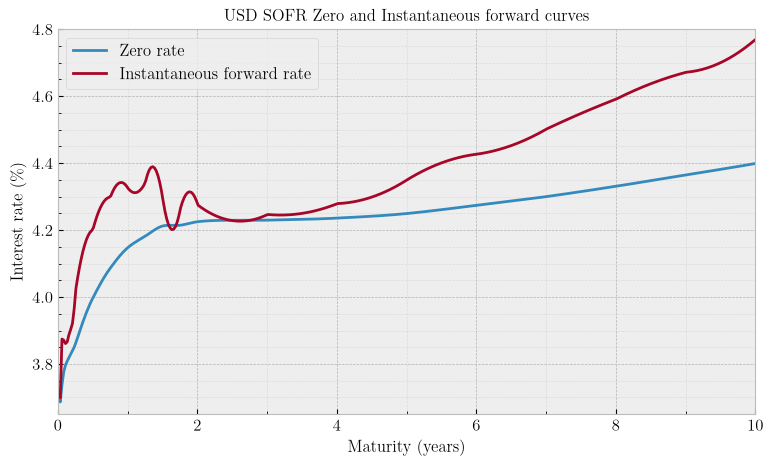

In [26]:
grid = np.linspace(0.01, node_times[-1], 2000)

zero = curve.zero_rate(grid)
forward = curve.instantaneous_forward(grid)


fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(grid, 100 * zero, label="Zero rate")
ax.plot(grid, 100 * forward, label="Instantaneous forward rate")

ax.set_xlabel("Maturity (years)")
ax.set_ylabel(r"Interest rate (\%)")
ax.set_title("USD SOFR Zero and Instantaneous forward curves")
ax.set_xlim(0, 10)
ax.set_ylim(3.65, 4.8)
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.grid(True, which="major")
ax.grid(True, which="minor", alpha=0.3)
ax.legend()

figures_path = Path("../results/figures")
interest_rates_path = figures_path / "zero_and_instantaneous_forward_rates.png"
plt.savefig(interest_rates_path, dpi=200, bbox_inches="tight")

plt.show()

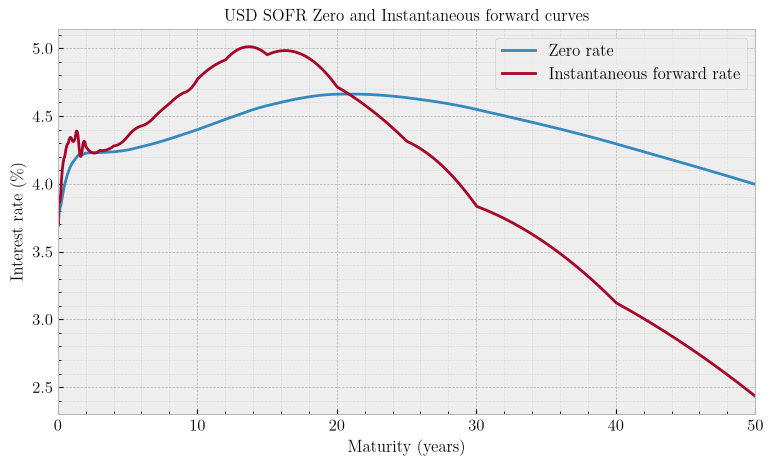

In [27]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(grid, 100 * zero, label="Zero rate")
ax.plot(grid, 100 * forward, label="Instantaneous forward rate")

ax.set_xlabel("Maturity (years)")
ax.set_ylabel(r"Interest rate (\%)")
ax.set_title("USD SOFR Zero and Instantaneous forward curves")
ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.set_xlim(0, 50)
ax.grid(True, which="major")
ax.grid(True, which="minor", alpha=0.3)

ax.legend()
plt.show()

The zero curve is smooth across the maturity range. The instantaneous-forward curve shows some local variation in the front end, particularly around the transaction-based CFTC nodes, but the large pathological spikes observed when fitting the irregular LCH maturity strip are no longer present.

The remaining local variation is consistent with fitting discrete transaction medians and is not large enough to justify introducing an additional smoothing penalty.

## 8. Held-out 3Y validation

The CFTC 3Y transaction median was deliberately excluded from calibration. Its comparison with the fitted 3Y spot-starting par rate, calculated using the pricing expression in Section 5, is an independent overlap check.

The diagnostic below reports market minus model in basis points; the in-sample residuals use model minus market.

In [28]:
# 3Y spot-starting OIS
start_3y = spot_date
maturity_3y = spot_date + pd.DateOffset(years=3)

payment_dates, accruals = fixed_leg_schedule(start_3y, maturity_3y)

start_time = (start_3y - market_date).days / 365.0

payment_times = np.array([(d - market_date).days / 365.0 for d in payment_dates])

df_start = curve.discount(start_time)
dfs = curve.discount(payment_times)

curve_3y = (df_start - dfs[-1]) / np.sum(accruals * dfs)

print(f"Curve 3Y par rate: {100 * curve_3y:.6f}%")
print(f"CFTC 3Y median:    {100 * cftc_3y:.6f}%")
print(f"Difference:        {1e4 * (cftc_3y - curve_3y):.3f} bp")

Curve 3Y par rate: 4.261000%
CFTC 3Y median:    4.264910%
Difference:        0.391 bp


The fitted curve and held-out CFTC 3Y median differ by approximately **0.4 bp**.

This provides an independent cross-source check that the combined LCH/CFTC curve is consistent around the transition from the CFTC gap-fill region to the LCH long end.

## 9. Freeze baseline curve

The validated node discount factors are exported for use by subsequent notebooks.

The discount factors are treated as the canonical saved representation of the curve. Zero rates and forward rates are derived quantities and can be regenerated from the exported nodes using the project `DiscountCurve`.

This freezes the **2 September 2026 USD SOFR baseline curve** for the subsequent swaption-calibration and CCR experiments.

In [29]:
curve_nodes = pchip_fitted[
    [
        "maturity",
        "start_date",
        "maturity_date",
        "time",
        "par_rate",
        "discount_factor",
    ]
].copy()

origin = pd.DataFrame({
    "maturity": ["0"],
    "start_date": [market_date],
    "maturity_date": [market_date],
    "time": [0.0],
    "par_rate": [np.nan],
    "discount_factor": [1.0],
})

curve_nodes = pd.concat([origin, curve_nodes], ignore_index=True)

curve_nodes.insert(0, "market_date", market_date)
curve_nodes.insert(1, "spot_date", spot_date)

In [30]:
processed_path = Path("../data/processed")

processed_path.mkdir(
    parents=True,
    exist_ok=True,
)

curve_path = (
    processed_path
    / "sofr_ois_pchip_curve_2026-09-02.csv"
)

curve_nodes.to_csv(
    curve_path,
    index=False,
)

print(f"Saved curve to: {curve_path}")

Saved curve to: ..\data\processed\sofr_ois_pchip_curve_2026-09-02.csv
